# LSTM model (A)

**Predict historical volatility using all data**

Author: Pete King

This notebook uses financial data to train a Long Short-Term Memory (LSTM) model to predict annualized return and volatility for a set of ETFs representing different market sectors.

In [1]:
#123456789012345678901234567890123456789012345678901234567890123456789012345678
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.preprocessing import MinMaxScaler

import data_prep as dp
import models

# Global variables
DATA_FILENAME = 'train_val_data.csv'
TICKERS_TO_REMOVE = ['XLRE']
VALIDATION_START_DATE = '2023-01-01'
SEQUENCE_LENGTH = 63  # Size of the rolling window for the Dataset
BATCH_SIZE = 5  # For DataLoader
BUFFER_SIZE = 63  # Number of business days between train and validation sets

## I. Data Preparation

### Import and inspect financial data

In [2]:
df = pd.read_csv(
    DATA_FILENAME,
    parse_dates=True
)
df

,date,nominal_GDP,real_GDP,debt_to_GDP,debt_interest,consumer_price_index,core_PCI,personal_consumption_expenditure,core_PCE,producer_price_index,...,TLT_logreturn_target,TLT_volatility_target,LQD_logreturn_target,LQD_volatility_target,HYG_logreturn_target,HYG_volatility_target,TIP_logreturn_target,TIP_volatility_target,GLD_logreturn_target,GLD_volatility_target
0,1927-12-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1928-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1928-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1928-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1928-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24569,2024-06-27,29147.044,23286.508,119.50314,1103.565,313.044,318.39,123.539,122.677,144.869,...,0.228628,0.143676,0.224334,0.062757,0.204915,0.037339,0.140210,0.040556,0.554863,0.144959
24570,2024-06-28,29147.044,23286.508,119.50314,1103.565,313.044,318.39,123.539,122.677,144.869,...,0.324501,0.138220,0.265942,0.061262,0.224723,0.036886,0.162335,0.040043,0.522621,0.146326
24571,2024-07-01,29511.664,23478.570,120.17172,1146.182,313.569,318.94,123.736,122.911,144.922,...,0.375021,0.133504,0.279868,0.060026,0.222517,0.036968,0.175744,0.039015,0.480090,0.147709
24572,2024-07-02,29511.664,23478.570,120.17172,1146.182,313.569,318.94,123.736,122.911,144.922,...,0.372776,0.133401,0.273494,0.059539,0.209581,0.036876,0.181298,0.039285,0.522023,0.148631


In [3]:
# Optionally remove ETFs from the series to make more training data available
df = dp.remove_series(df, TICKERS_TO_REMOVE).dropna().copy()

### Split data into training and validation sets

In [4]:
train_df, val_df = dp.time_series_split(
    df, VALIDATION_START_DATE, BUFFER_SIZE
)

In [5]:
# Get separate lists of data (X) and label (y) columns
X_cols, y_cols = dp.get_X_y_cols(train_df, label_marker='GLD_volatility_target')

In [6]:
# Inspect the sample data to confirm start/stop dates
train_df[['date'] + X_cols]

,date,nominal_GDP,real_GDP,debt_to_GDP,debt_interest,consumer_price_index,core_PCI,personal_consumption_expenditure,core_PCE,producer_price_index,...,IEF_volatility_target,TLT_logreturn_target,TLT_volatility_target,LQD_logreturn_target,LQD_volatility_target,HYG_logreturn_target,HYG_volatility_target,TIP_logreturn_target,TIP_volatility_target,GLD_logreturn_target
20788,2009-11-02,14651.249,16502.754,84.02935,353.811,217.234,220.666,89.887,89.160,100.200,...,0.058938,-0.161767,0.115049,0.039882,0.053683,0.157986,0.061765,0.068215,0.046358,0.178727
20789,2009-11-03,14651.249,16502.754,84.02935,353.811,217.234,220.666,89.887,89.160,100.200,...,0.061042,-0.058772,0.117983,0.057824,0.052816,0.091902,0.068495,0.086963,0.046363,-0.079308
20790,2009-11-04,14651.249,16502.754,84.02935,353.811,217.234,220.666,89.887,89.160,100.200,...,0.061079,-0.013342,0.116661,0.029935,0.052681,0.062340,0.069573,0.072026,0.046447,-0.091420
20791,2009-11-05,14651.249,16502.754,84.02935,353.811,217.234,220.666,89.887,89.160,100.200,...,0.061115,-0.008129,0.116693,0.031090,0.052696,0.041599,0.070171,0.058241,0.046464,-0.111466
20792,2009-11-06,14651.249,16502.754,84.02935,353.811,217.234,220.666,89.887,89.160,100.200,...,0.061840,-0.052146,0.118374,0.011248,0.052659,0.045894,0.070251,0.034513,0.046803,-0.075928
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24118,2022-09-27,26336.304,22125.625,117.43832,752.081,296.349,298.226,117.371,115.788,140.200,...,0.110938,0.006324,0.225042,0.214090,0.137829,0.210513,0.138690,0.062319,0.099730,0.428378
24119,2022-09-28,26336.304,22125.625,117.43832,752.081,296.349,298.226,117.371,115.788,140.200,...,0.101717,-0.149048,0.215146,0.121937,0.132477,0.085570,0.137318,-0.012258,0.093377,0.328020
24120,2022-09-29,26336.304,22125.625,117.43832,752.081,296.349,298.226,117.371,115.788,140.200,...,0.101745,-0.083143,0.216235,0.180190,0.132125,0.174754,0.138104,0.060670,0.089253,0.351126
24121,2022-09-30,26336.304,22125.625,117.43832,752.081,296.349,298.226,117.371,115.788,140.200,...,0.101964,-0.075909,0.215835,0.164988,0.132722,0.196462,0.137683,0.076023,0.088340,0.369539


In [7]:
# Inspect dates for validation set; confirm buffer size
val_df[['date'] + y_cols]

,date,GLD_volatility_target
24186,2023-01-03,0.166973
24187,2023-01-04,0.166261
24188,2023-01-05,0.164782
24189,2023-01-06,0.161979
24190,2023-01-09,0.162308
...,...,...
24568,2024-06-26,0.145985
24569,2024-06-27,0.144959
24570,2024-06-28,0.146326
24572,2024-07-02,0.148631


### Scale data

Since our data is heterogeneous, we scale each feature to a range between \[0, 1\].  This prevents features with large values from dominating the parameter optimization process.  We fit the scaler object to the training data only, so that information about the validation set is not transfered to the training set (i.e., guard against data leakage). 

In [8]:
scaler = MinMaxScaler()
# Get scaled data (X) for training and validation
X_train = scaler.fit_transform(train_df[X_cols].values)
X_val = scaler.transform(val_df[X_cols].values)
# Get labels as NumPy array (no scaling)
y_train = train_df[y_cols].values
y_val = val_df[y_cols].values

## II. PyTorch Multivariate LSTM Model

In this section we use the PyTorch library to create Datasets and DataLoaders that we will use to introduce training samples to the LSTM model in batches.

The custom FinancialDataset implements a rolling window that captures a series of data points from time (t - L) to time (t - 1), where L is the size of the rolling window (i.e., sequence length).  Thus each data sample is a matrix with dimensions (num_features, L), where num_features is the number of features in each data instance.

The label for each data sample at time t was computed earlier using values for historical return and volatility after time t.  This forward-looking computation of the label is the reason we implement a buffer between training and validation sets -- to guard against data leakage.

### Create Datasets and DataLoaders

In [9]:
# Model Training
train_dataset = dp.FinancialDataset(
    X_train.astype(np.float32),  # float32 required for LSTM
    y_train.astype(np.float32),
    sequence_length=SEQUENCE_LENGTH
)
train_dataloader = dp.DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False
)

# Model Evaluation
val_dataset = dp.FinancialDataset(
    X_val.astype(np.float32),  # float32 required for LSTM
    y_val.astype(np.float32),
    sequence_length=SEQUENCE_LENGTH
)
val_dataloader = dp.DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False
)

In [10]:
# Inspect first sample and label in training dataset
X_0, y_0 = train_dataset[0]
print(f'Shape of first training sample: {X_0.shape}')
print(f'Shape of first training label: {y_0.shape}')

Shape of first training sample: torch.Size([63, 88])
Shape of first training label: torch.Size([1])


In [11]:
# Inspect batch dimensions from dataloader
batched_data_0, batched_labels_0 = next(iter(train_dataloader))
print(f'Shape of first batch of data: {batched_data_0.shape}')
print(f'Shape of first batch of labels: {batched_labels_0.shape}')

Shape of first batch of data: torch.Size([5, 63, 88])
Shape of first batch of labels: torch.Size([5, 1])


### Instantiate and train LSTM model

In [12]:
# Define LSTM parameters
input_size = len(X_cols)  # Number of features in data (x)
hidden_size = 128  # Number of 'neurons' (features) in each hidden layer
num_layers = 1  # Number of LSTM layers in the model stack
batch_first = True  # Determines order of dimensions for input/output tensors
bidirectional = False  # If True, becomes a bidirectional LSTM
proj_size = 0  # If > 0, will use LSTM with projections of corresponding size

# Define variables for LSTM input/output tensor dimensions IAW PyTorch docs
N = BATCH_SIZE  # Batch size
L = SEQUENCE_LENGTH  # Sequence length (number of timestamps in rolling window)
D = int(bidirectional) + 1   # D = 1 (not birectional) or 2 (bidirectional)
H_in = input_size
H_cell = hidden_size
H_out = (proj_size if proj_size > 0 else H_in)

# Define number of dimensions in target labels (y) for multivariate LSTM
label_size = len(y_cols)

In [13]:
# Set an accelerator device (e.g., CUDA) if available.
if torch.accelerator.is_available():
    device = torch.accelerator.current_accelerator().type
else:
    device = 'cpu'

print(f'Device: {device}')

Device: cpu


In [14]:
# Instantiate LSTM and assign to device
model = models.FinancialLSTM(
    input_size=input_size,
    label_size=label_size,
    hidden_size=hidden_size,
    num_layers=num_layers,
    batch_first=batch_first,
    bidirectional=bidirectional,
    proj_size=proj_size
).to(device)
print(model)

FinancialLSTM(
  (lstm): LSTM(88, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)


In [15]:
# Define loss function and optimizer
# For multivariate loss, set parameter reduction='none'
loss_fn = torch.nn.L1Loss(reduction='mean')
optimizer = torch.optim.Adam(model.parameters())

In [16]:
# Train and evaluate model
epochs = 100
all_preds = []
print(f'Training model over {epochs} epochs...')
for epoch in range(epochs):
    loss_trn = models.train_model(train_dataloader, model, loss_fn, optimizer)
    loss_val, preds = models.evaluate_model(val_dataloader, model, loss_fn)
    all_preds.append(preds)
    if epochs <= 20:
        print(f'Epoch {epoch + 1}')
        print(f'Training loss:   {loss_trn}')
        print(f'Validation loss: {loss_val}')
    else:
        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch + 1}')
            print(f'Training loss:   {loss_trn}')
            print(f'Validation loss: {loss_val}')

Training model over 100 epochs...
Epoch 10
Training loss:   0.026055678725242615
Validation loss: 0.008435492403805256
Epoch 20
Training loss:   0.026920605450868607
Validation loss: 0.019804075360298157
Epoch 30
Training loss:   0.02676321566104889
Validation loss: 0.011148005723953247
Epoch 40
Training loss:   0.020611807703971863
Validation loss: 0.0013306885957717896
Epoch 50
Training loss:   0.013345450162887573
Validation loss: 0.015442858450114727
Epoch 60
Training loss:   0.016226965934038162
Validation loss: 0.021824663504958153
Epoch 70
Training loss:   0.00893041118979454
Validation loss: 0.03312687948346138
Epoch 80
Training loss:   0.005695618689060211
Validation loss: 0.03763626888394356
Epoch 90
Training loss:   0.0040447525680065155
Validation loss: 0.032821983098983765
Epoch 100
Training loss:   0.009958863258361816
Validation loss: 0.03008289635181427


We see no clear trend for either the training loss or validation loss, with values tending to bounce around between epochs.  I have tried many (unlogged) variations with up to 100 epochs, but the validation loss consistently tends to bounce around initially and then often will steadily increase.  **Something is clearly wrong with the setup.**  Will require some troubleshooting.

Some ideas:

 1. First, fix the business day issue.  The original time series contains timestamps on Saturdays, Sundays, and other non-business days.  This could be throwing off the computations.  Certinaly, the "63 business day" gap we inted for a buffer is not actually 63 business days.  (*Note: this issue was subsequently fixed and is not longer reflected in the data.*)
 2. Instead of predicting computed future return and volatility values, try predicting the value (price) for the ETF at the next time step.  From this predicted series, compute annualized return and volatility forecasts, then compare the forecasts to the true historical (observed) values.
 3. A multivariate LSTM may present too many dimensions/parameters with such little data.  Consider a series of single-variable LSTM models (one for each ETF), or other ways to reduce the dimensionality of the input features.
 4. As a corollary to (2) above, consider using macroeconomic variables and market sentiment indicators in some other way.  Possibly approach as an (ordinal) classification problem (i.e., predict a general "market regime").  This would serve to considerably reduce the dimensionality of the input features.  Then use the prediction as a One-Hot-Encoded input feature, or as a discrete random variable against which we compute some kind of conditional volatility/return.

## III. Analyze Results

### Plot of predictions vs labels (final epoch)


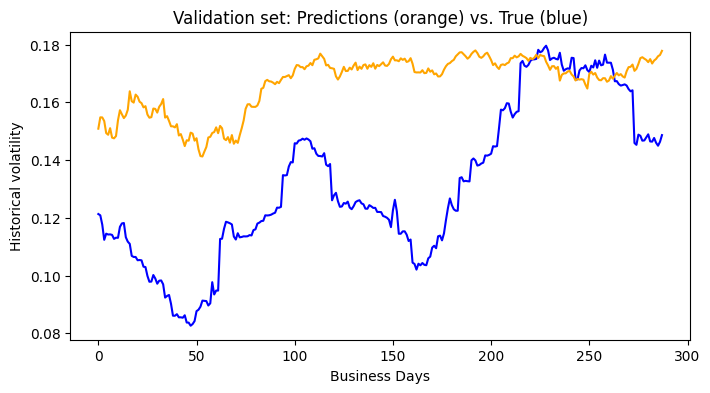

In [18]:
fig = plt.figure(figsize=(8, 4))
ax = fig.subplots()

x = range(len(val_dataset))
labels = [val_dataset[i][1]for i in range(len(x))]
ax.set_title('Validation set: Predictions (orange) vs. True (blue)')
ax.set_ylabel('Historical volatility')
ax.set_xlabel('Business Days')
ax.plot(x, labels, color='blue')
ax.plot(x, preds, color='orange')